In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.integrate as integrate
from tqdm import tqdm

# To render as in Latex font
'''params = {
   'axes.labelsize': 18,
   'font.size': 18,
   'legend.fontsize': 18,
   'xtick.labelsize': 18,
   'ytick.labelsize': 18,
   'axes.titlesize': 18,
   'text.usetex': True,
   'font.family':'serif',
   'font.serif':'Computer Modern',
   'figure.dpi': 150
   }
plt.rcParams.update(params)
plt.rcParams["font.serif"] = "Computer Modern Roman"
plt.rcParams["font.family"] = "Serif"'''

'params = {\n   \'axes.labelsize\': 18,\n   \'font.size\': 18,\n   \'legend.fontsize\': 18,\n   \'xtick.labelsize\': 18,\n   \'ytick.labelsize\': 18,\n   \'axes.titlesize\': 18,\n   \'text.usetex\': True,\n   \'font.family\':\'serif\',\n   \'font.serif\':\'Computer Modern\',\n   \'figure.dpi\': 150\n   }\nplt.rcParams.update(params)\nplt.rcParams["font.serif"] = "Computer Modern Roman"\nplt.rcParams["font.family"] = "Serif"'

In [2]:
%run two_level_funcs.py

In [3]:
T = 10 # total time (input pulse "duration")
N = 8000 # number of time steps

mu, sigma = 2.5, 0.5 # defined for a Gaussian input

# Returned area-normalized Gaussian
def gaussian(mu, sigma, t):
    return np.sqrt(1/(sigma*np.sqrt(np.pi))) * np.exp(-((t-mu)**2) / (2*sigma**2))

### INPUT COHERENT STATE
def alpha_in(t):
    a = 0.1 # small amplitude
    return a*(gaussian(mu, sigma, t)) # + np.random.normal(0, sigma*0.01, 1)) # Gaussian input

### TEMPLATE FUNCTION (k(t) = template at time t)
def k(t):
    return gaussian(mu, sigma, t) # for perfectly overlapping Gaussian template (change mu to diff values for time shift)
def k_orthogonal(t):
    return gaussian(mu, sigma, t) * np.sin(t-mu) # for orthogonal template (to input)

### COUPLING FUNCTION (g(t) = coupling strength between atom and light at time t)
def g(t):
    integral_value, _ = integrate.quad(lambda x: np.abs(k(x))**2, 0, t) # Denominator -inf to t
    return k(t) / np.sqrt(integral_value) if integral_value > 0 else 0
def g_orthogonal(t):
    integral_value, _ = integrate.quad(lambda x: np.abs(k_orthogonal(x))**2, 0, t) # Denominator -inf to t
    return k_orthogonal(t) / np.sqrt(integral_value) if integral_value > 0 else 0

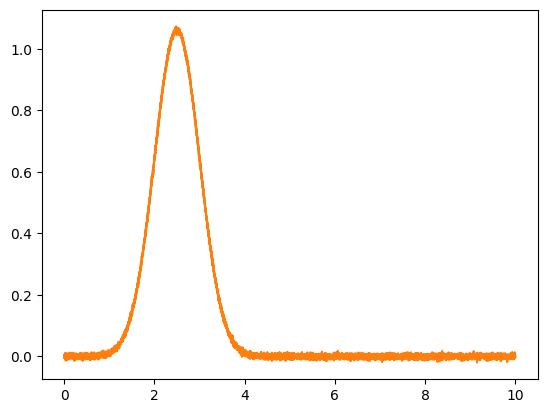

In [51]:
plt.plot(np.linspace(0, T, N), gaussian(mu, sigma, np.linspace(0, T, N)))
plt.plot(np.linspace(0, T, N), gaussian(mu, sigma, np.linspace(0, T, N)) + np.random.normal(0, sigma*0.01, N))

Starting in the GROUND STATE

In [4]:
time, alpha, g_vals, g_vals_smoothed, k_vals, S, S_ideal, prob_ground, prob_excited = simulate_two_level(alpha_in, g, k, T, N)

print("Area of alpha:", integrate.simps(alpha**2, time))
print("Area of template k(t):", integrate.simps(np.array(k_vals)**2, time))
print('Final S: ', abs(S[-1]))
print("Max excited state population:", max(prob_excited))
print("Final excited state population:", prob_excited[-1])

Area of alpha: 0.00999999999999231
Area of template k(t): 0.9999999999992312
Final S:  0.09900437994022486
Max excited state population: (0.009933614703542953+0j)
Final excited state population: (0.00993357950308168+0j)


In [6]:
# Simulate for orthogonal template
time_o, alpha_o, g_vals_o, g_vals_smoothed_o, k_vals_o, S_o, S_ideal_o, prob_ground_o, prob_excited_o = simulate_two_level(alpha_in, g_orthogonal, k_orthogonal, T, N)

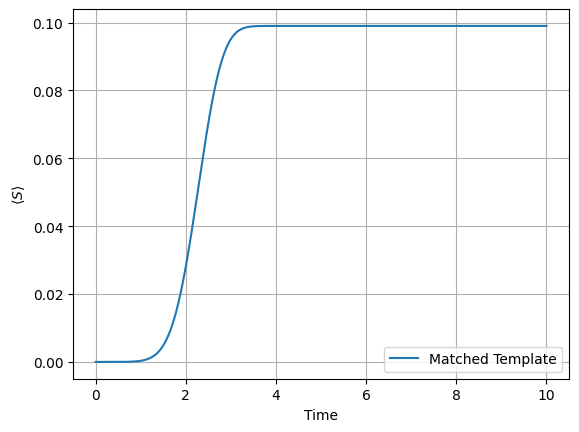

In [5]:
#plt.plot(time, abs(S_o), label='Orthogonal Template', color='tab:orange')
plt.plot(time, abs(S), label='Matched Template', color='tab:blue')
plt.ylabel(r'$\langle S \rangle$'); plt.xlabel('Time'); plt.grid()
plt.legend()

(0.0, 0.02)

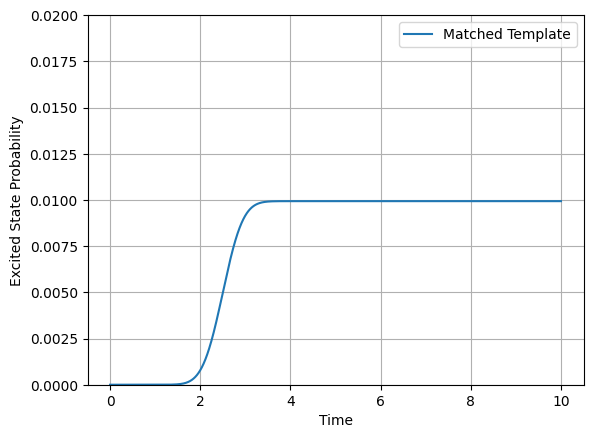

In [6]:
plt.plot(time, abs(prob_excited), label='Matched Template', color='tab:blue')
#plt.plot(time, abs(prob_excited_o), label='Orthogonal Template', color='tab:orange')
plt.legend(); plt.grid(); plt.xlabel('Time')
plt.ylabel('Excited State Probability')
plt.ylim([0, 0.02])

C:\Users\bac06\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\matplotlib\cbook\__init__.py:1369: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


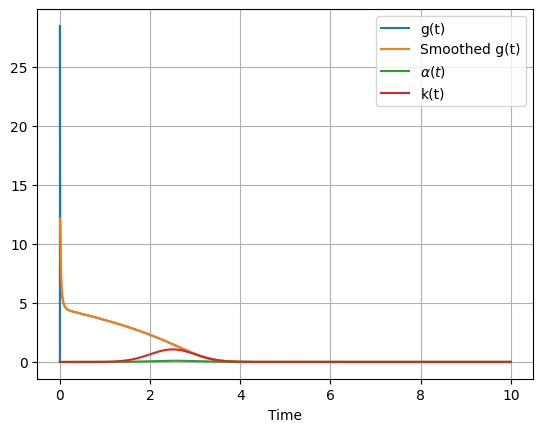

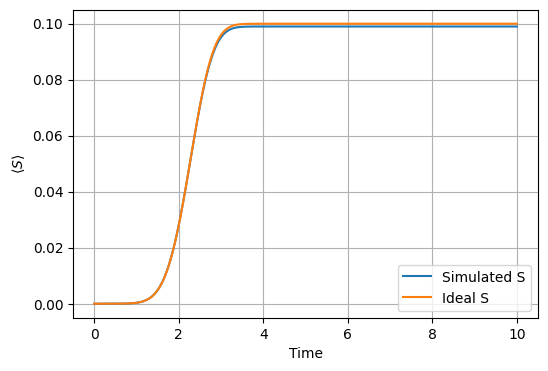

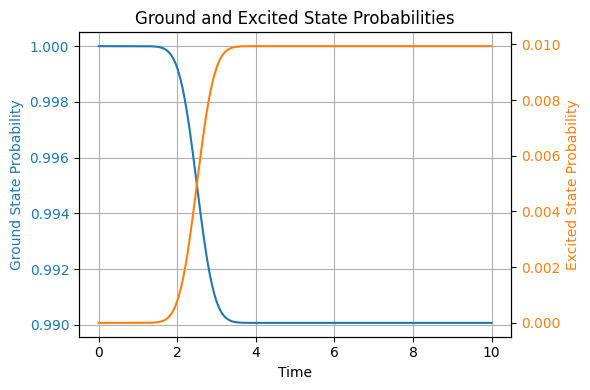

In [7]:
### PLOT INPUT VALUES
plt.figure()
plt.plot(time, g_vals, label='g(t)')
plt.plot(time, g_vals_smoothed, label='Smoothed g(t)')  # Plot smoothed g(t)
plt.plot(time, alpha_in(time), label=r'$\alpha(t)$')
plt.plot(time, k_vals, label='k(t)')
plt.legend(); plt.grid(); plt.xlabel('Time')

### PLOT SPIN EXPECTATION VALUES
plt.figure(figsize=(6,4))
plt.plot(time, abs(S), label='Simulated S')
plt.plot(time, np.abs(S_ideal), label='Ideal S')
plt.ylabel(r'$\langle S \rangle$'); plt.xlabel('Time'); plt.grid(); plt.legend()

# PLOT PROBABILITIES
fig, ax1 = plt.subplots(figsize=(6, 4))
color = 'tab:blue'
ax1.set_xlabel('Time')
ax1.set_ylabel('Ground State Probability', color=color)
ax1.plot(time, prob_ground, label='Ground State', color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid()

ax2 = ax1.twinx()
color = 'tab:orange'
ax2.set_ylabel('Excited State Probability', color=color)
ax2.plot(time, prob_excited, label='Excited State', color=color)
ax2.tick_params(axis='y', labelcolor=color)
plt.title('Ground and Excited State Probabilities')
plt.tight_layout()
plt.show()

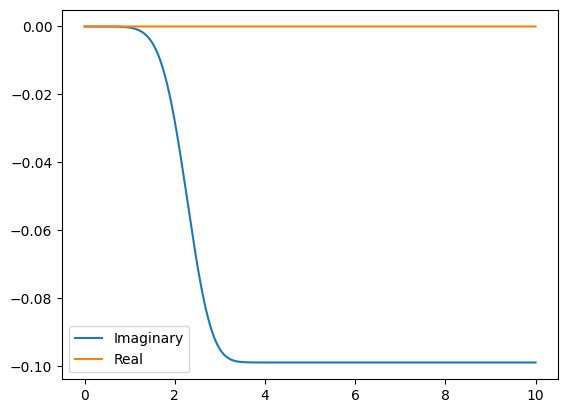

In [8]:
plt.plot(time, np.imag(S), label='Imaginary')
plt.plot(time, np.real(S), label='Real')
plt.legend()

In [9]:
S

array([0.+0.00000000e+00j, 0.-5.37458555e-09j, 0.-1.06259329e-08j, ...,
       0.-9.90043799e-02j, 0.-9.90043799e-02j, 0.-9.90043799e-02j])

In [10]:
np.conjugate(g_vals)[1]

28.459415074891922

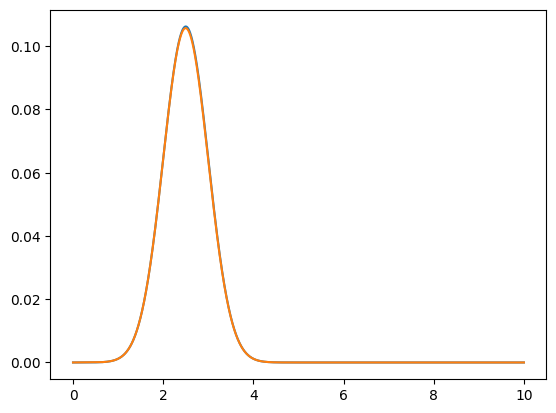

In [19]:
#plt.plot(time, alpha - abs(S)*(np.conjugate(g_vals_smoothed)), label=r'$\alpha-|gS|$')
#plt.plot(time, np.conjugate(g_vals_smoothed), label=r'$g^*$')

plt.plot(time, alpha)
plt.plot(time, abs(S)*g_vals, label=r'$|S|g(t)$')

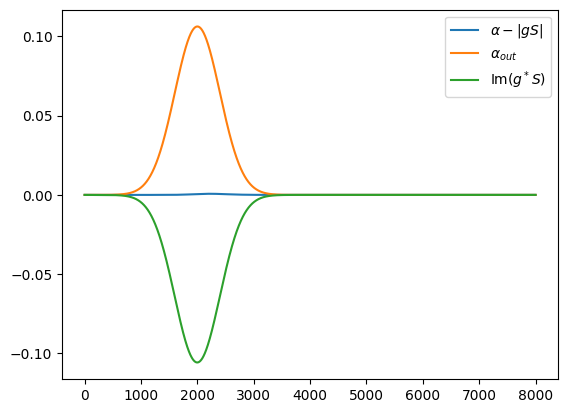

In [13]:
#plt.plot(alpha, label=r'$\alpha_{in}$')
plt.plot(alpha - abs(S)*(np.conjugate(g_vals_smoothed)), label=r'$\alpha-|gS|$')

alpha_out = alpha - np.conjugate(g_vals_smoothed)*S
plt.plot(alpha_out, label=r'$\alpha_{out}$')

#plt.plot(np.real(np.conjugate(g_vals)*S), label=r'$\mathrm{Re}(g^*S)$')
plt.plot(np.imag(np.conjugate(g_vals)*S), label=r'$\mathrm{Im}(g^*S)$')
plt.legend()
# Tried: making g imaginary, but this makes S real so the same problem arises.
# Signal should accumulate phase of pi while interacting with the atom.

How precisely in time must the input signal and coupling pulse overlap? i.e. how is S affected?

In [ ]:
time_shift = np.linspace(-sigma, sigma, 30)
max_S_arr = []

plt.figure()
plt.plot(time, alpha, color='blue', label=r'$\alpha(t)$')

for i in tqdm(range(0, len(time_shift))):
    def k(t):
        return gaussian(mu+time_shift[i], sigma, t) # for perfectly overlapping Gaussian template (change mu to diff values for time shift)
    time, alpha, g_vals, g_vals_smoothed, k_vals, S, S_ideal, prob_ground, prob_excited = simulate_two_level(alpha_in, g, k, T, N)
    if i % 5 == 0:
        if i == 5: glabel = 'g(t)'; klabel = 'k(t)'
        else:      glabel=''; klabel=''
        plt.plot(time, g_vals, color='orange', label=glabel)
        plt.plot(time, k_vals, color='green', label=klabel)
    max_S_arr.append(abs(S[-1]))

plt.xlabel('Time'); plt.legend()
plt.ylim([0, 6])

 20%|██        | 6/30 [00:34<02:35,  6.48s/it]

Text(0, 0.5, '$\\langle S \\rangle$')

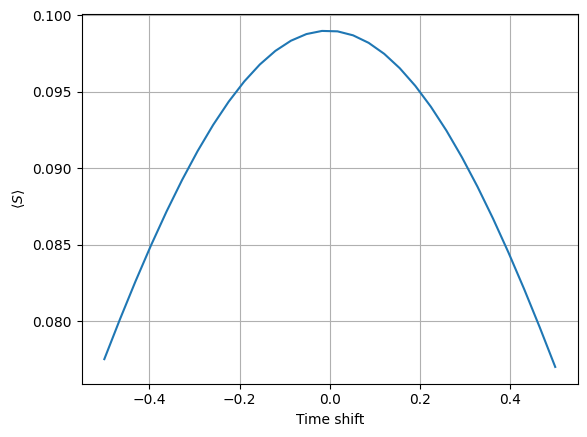

In [ ]:
plt.figure()
plt.plot(time_shift, max_S_arr)
plt.grid()
plt.xlabel('Time shift')
plt.ylabel(r'$\langle S \rangle$')